In [37]:
import scvelo as scv
import scanpy as sc
from multiprocessing import Pool
import anndata as ad
import numpy as np
import pandas as pd
from matplotlib import rcParams

In [38]:
import mudata as mu

In [103]:
import scanpy as sc

scv.settings.figdir = "/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/publication_figures/healthy"


In [39]:
adata = ad.read_h5ad("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/single_cell_normal/002_annotate_adata_normal.h5ad")


In [40]:
adata = adata[~adata.obs_names.duplicated(), :]

In [41]:
adata

View of AnnData object with n_obs × n_vars = 18263 × 18038
    obs: 'sample_id', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'rna_leiden_2', 'cell_annotation_05'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
    uns: 'cell_annotation_05_colors', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'rna_leiden', 'rna_leiden_12', 'rna_leiden_

In [42]:
import os
import glob
import scvelo as scv
import scanpy as sc

def read_scvelo_2019_looms():
    loom_dir = "/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/trajectory_inference/loom"
    
    # find all loom files starting with 2021
    loom_files = sorted(
        glob.glob(os.path.join(loom_dir, "2019*.loom"))
    )
    
    print(f"Found {len(loom_files)} loom files.")
    
    adatas = []
    
    for file in loom_files:
        print(f"Reading {os.path.basename(file)}")
        
        adata = scv.read_loom(file)
        adata.var_names_make_unique()
        
        # store filename (without extension) as metadata
        sample_name = os.path.basename(file).replace(".loom", "")
        adata.obs["sample_id"] = sample_name
        
        adatas.append(adata)
    
    # concatenate all
    adata_combined = sc.concat(adatas, join="outer", label="batch", keys=[a.obs["sample_id"][0] for a in adatas])
    
    return adata_combined


In [43]:
adata_velocity = read_scvelo_2019_looms()

Found 5 loom files.
Reading 2019_10mix1.loom
Reading 2019_10mix2.loom
Reading 2019_11mix1.loom
Reading 2019_11mix2.loom
Reading 2019_GF1.loom


In [44]:
adata_scvelo = adata_velocity

In [45]:
adata_scvelo

AnnData object with n_obs × n_vars = 24112 × 32285
    obs: 'sample_id', 'batch'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [46]:
adata.obs_names

Index(['AAACCTGAGTCTTGCA-1_10mix1', 'AAACCTGAGTTAAGTG-1_10mix1',
       'AAACCTGCAGGATCGA-1_10mix1', 'AAACCTGCATAACCTG-1_10mix1',
       'AAACCTGCATACCATG-1_10mix1', 'AAACCTGCATTGAGCT-1_10mix1',
       'AAACCTGGTGTGCCTG-1_10mix1', 'AAACCTGTCGCCCTTA-1_10mix1',
       'AAACGGGCAAGGGTCA-1_10mix1', 'AAACGGGCAAGGTTCT-1_10mix1',
       ...
       'TTTATGCCAGCTGCAC-1_GF2', 'TTTCCTCAGGAATGGA-1_GF2',
       'TTTCCTCTCATAGCAC-1_GF2', 'TTTGCGCAGGGAGTAA-1_GF2',
       'TTTGCGCTCAACCATG-1_GF2', 'TTTGCGCTCGGTGTTA-1_GF2',
       'TTTGTCAAGGCTAGCA-1_GF2', 'TTTGTCAAGTGCCAGA-1_GF2',
       'TTTGTCAAGTTGTCGT-1_GF2', 'TTTGTCATCGATGAGG-1_GF2'],
      dtype='object', length=18263)

In [47]:
import re

# Step 1: extract clean barcode
barcodes = (
    adata_scvelo.obs_names
    .str.split(":").str[1]      # take part after :
    .str.replace("x", "", regex=False)  # remove trailing x
)

# Step 2: clean sample names
samples = (
    adata_scvelo.obs["sample_id"]
    .str.replace("2019_", "", regex=False)
)

# Step 3: build matching obs_names
new_names = samples + "_" + barcodes + "-1"

adata_scvelo.obs_names = new_names


In [48]:
adata_scvelo.obs

,sample_id,batch
10mix1_AAAGCAAGTGAGGCTA-1,2019_10mix1,2019_10mix1
10mix1_AACTCAGTCGCGTTTC-1,2019_10mix1,2019_10mix1
10mix1_AAAGTAGGTTCCGTCT-1,2019_10mix1,2019_10mix1
10mix1_AAATGCCAGTAGCCGA-1,2019_10mix1,2019_10mix1
10mix1_AACTCAGCATTTCACT-1,2019_10mix1,2019_10mix1
...,...,...
GF1_TTTGTCACAATCCGAT-1,2019_GF1,2019_GF1
GF1_TTTCCTCGTGTCGCTG-1,2019_GF1,2019_GF1
GF1_TTTCCTCTCTAACCGA-1,2019_GF1,2019_GF1
GF1_TTTGCGCAGTGTGGCA-1,2019_GF1,2019_GF1


In [49]:
adata.obs_names

Index(['AAACCTGAGTCTTGCA-1_10mix1', 'AAACCTGAGTTAAGTG-1_10mix1',
       'AAACCTGCAGGATCGA-1_10mix1', 'AAACCTGCATAACCTG-1_10mix1',
       'AAACCTGCATACCATG-1_10mix1', 'AAACCTGCATTGAGCT-1_10mix1',
       'AAACCTGGTGTGCCTG-1_10mix1', 'AAACCTGTCGCCCTTA-1_10mix1',
       'AAACGGGCAAGGGTCA-1_10mix1', 'AAACGGGCAAGGTTCT-1_10mix1',
       ...
       'TTTATGCCAGCTGCAC-1_GF2', 'TTTCCTCAGGAATGGA-1_GF2',
       'TTTCCTCTCATAGCAC-1_GF2', 'TTTGCGCAGGGAGTAA-1_GF2',
       'TTTGCGCTCAACCATG-1_GF2', 'TTTGCGCTCGGTGTTA-1_GF2',
       'TTTGTCAAGGCTAGCA-1_GF2', 'TTTGTCAAGTGCCAGA-1_GF2',
       'TTTGTCAAGTTGTCGT-1_GF2', 'TTTGTCATCGATGAGG-1_GF2'],
      dtype='object', length=18263)

In [50]:
len(set(adata.obs_names)), len(set(adata_scvelo.obs_names)), len(
    set(adata.obs_names) & set(adata_scvelo.obs_names)
)

(18263, 24112, 0)

In [51]:
adata_scvelo = scv.utils.merge(adata_scvelo, adata)

In [52]:
scv.pp.filter_and_normalize(adata_scvelo)

Normalized count data: X, spliced, unspliced.
Logarithmized X.


/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


In [53]:
scv.pp.moments(adata_scvelo, n_pcs=30, n_neighbors=30)

computing neighbors
    finished (0:00:05) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:03) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [54]:
scv.tl.velocity(adata_scvelo)

computing velocities


/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:15) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [55]:
scv.tl.velocity_graph(adata_scvelo)

computing velocity graph (using 1/144 cores)


  0%|          | 0/11351 [00:00<?, ?cells/s]

    finished (0:00:07) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [56]:
adata_scvelo

AnnData object with n_obs × n_vars = 11351 × 18038
    obs: 'sample_id', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'sample_batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'rna_leiden_2', 'cell_annotation_05', 'n_counts', 'velocity_self_transition'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells', 'gene_count_corr', 'velocity_gamma', 'vel

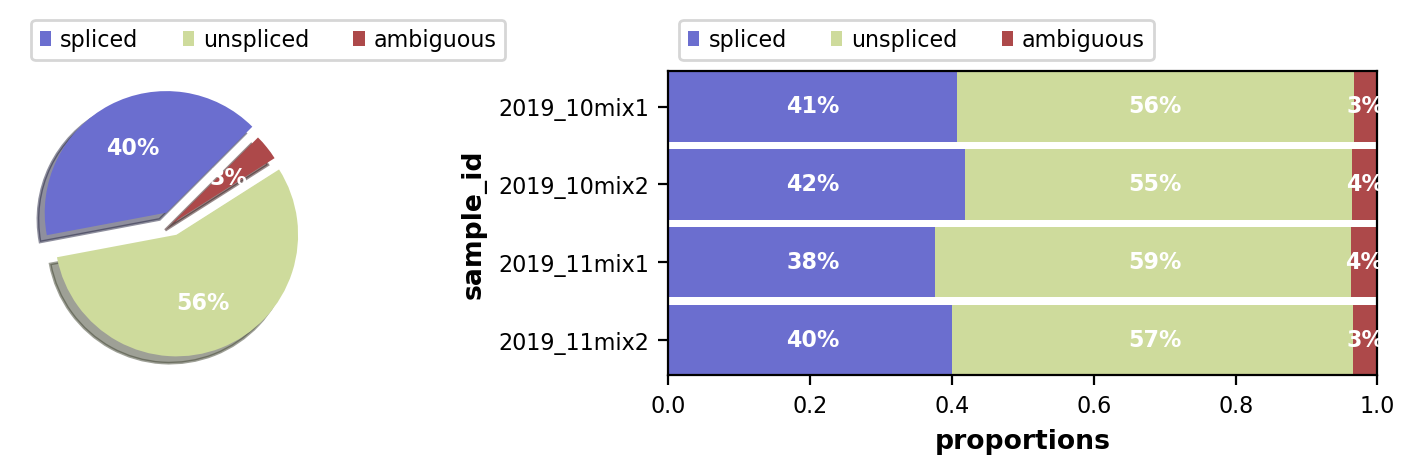

In [57]:
scv.pl.proportions(adata_scvelo, groupby="sample_id")

In [58]:
sc.set_figure_params(figsize=(10, 10))
rcParams["axes.grid"] = False


/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scanpy/_settings.py:450: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  IPython.display.set_matplotlib_formats(*ipython_format)


In [59]:
adata

AnnData object with n_obs × n_vars = 18263 × 18038
    obs: 'sample_id', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'rna_leiden_2', 'cell_annotation_05', 'sample_batch'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
    uns: 'cell_annotation_05_colors', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'rna_leiden', 'rna_leiden_12', 'rna

/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/kvalem/.conda/envs/scvelo_03_2024/lib

saving figure to file /data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/publication_figures/healthy/scvelo_velocity_normal_rna_leiden_12.png


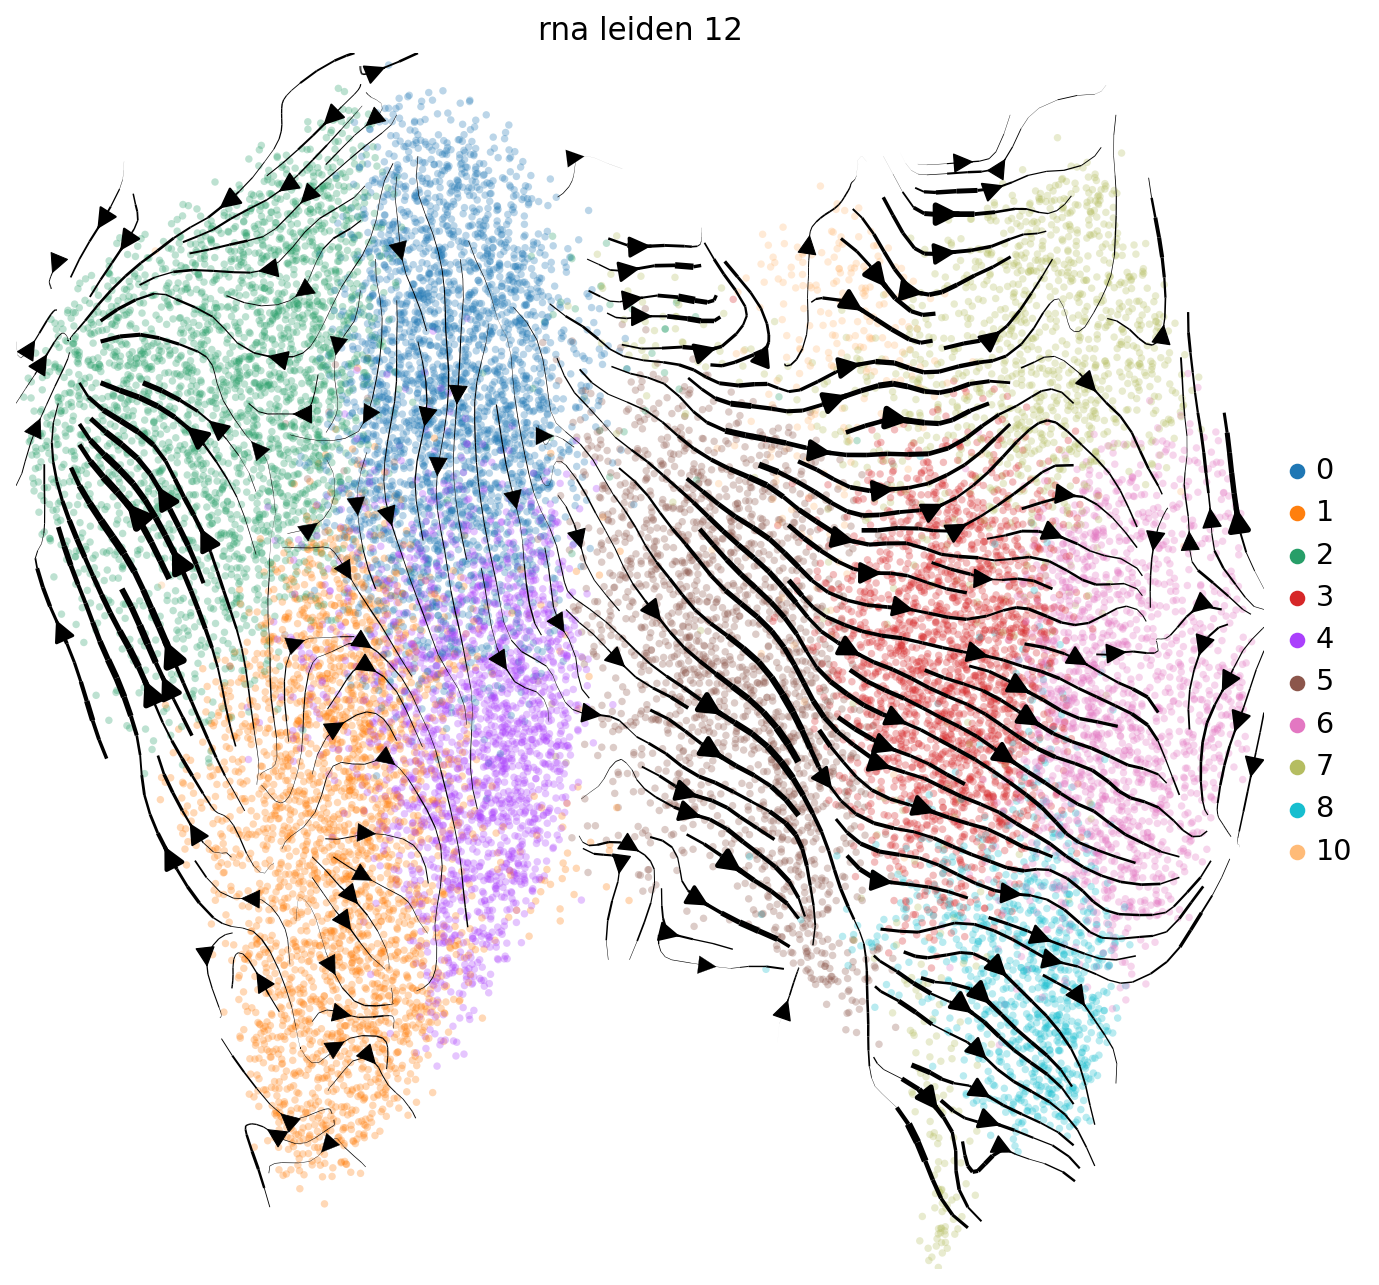

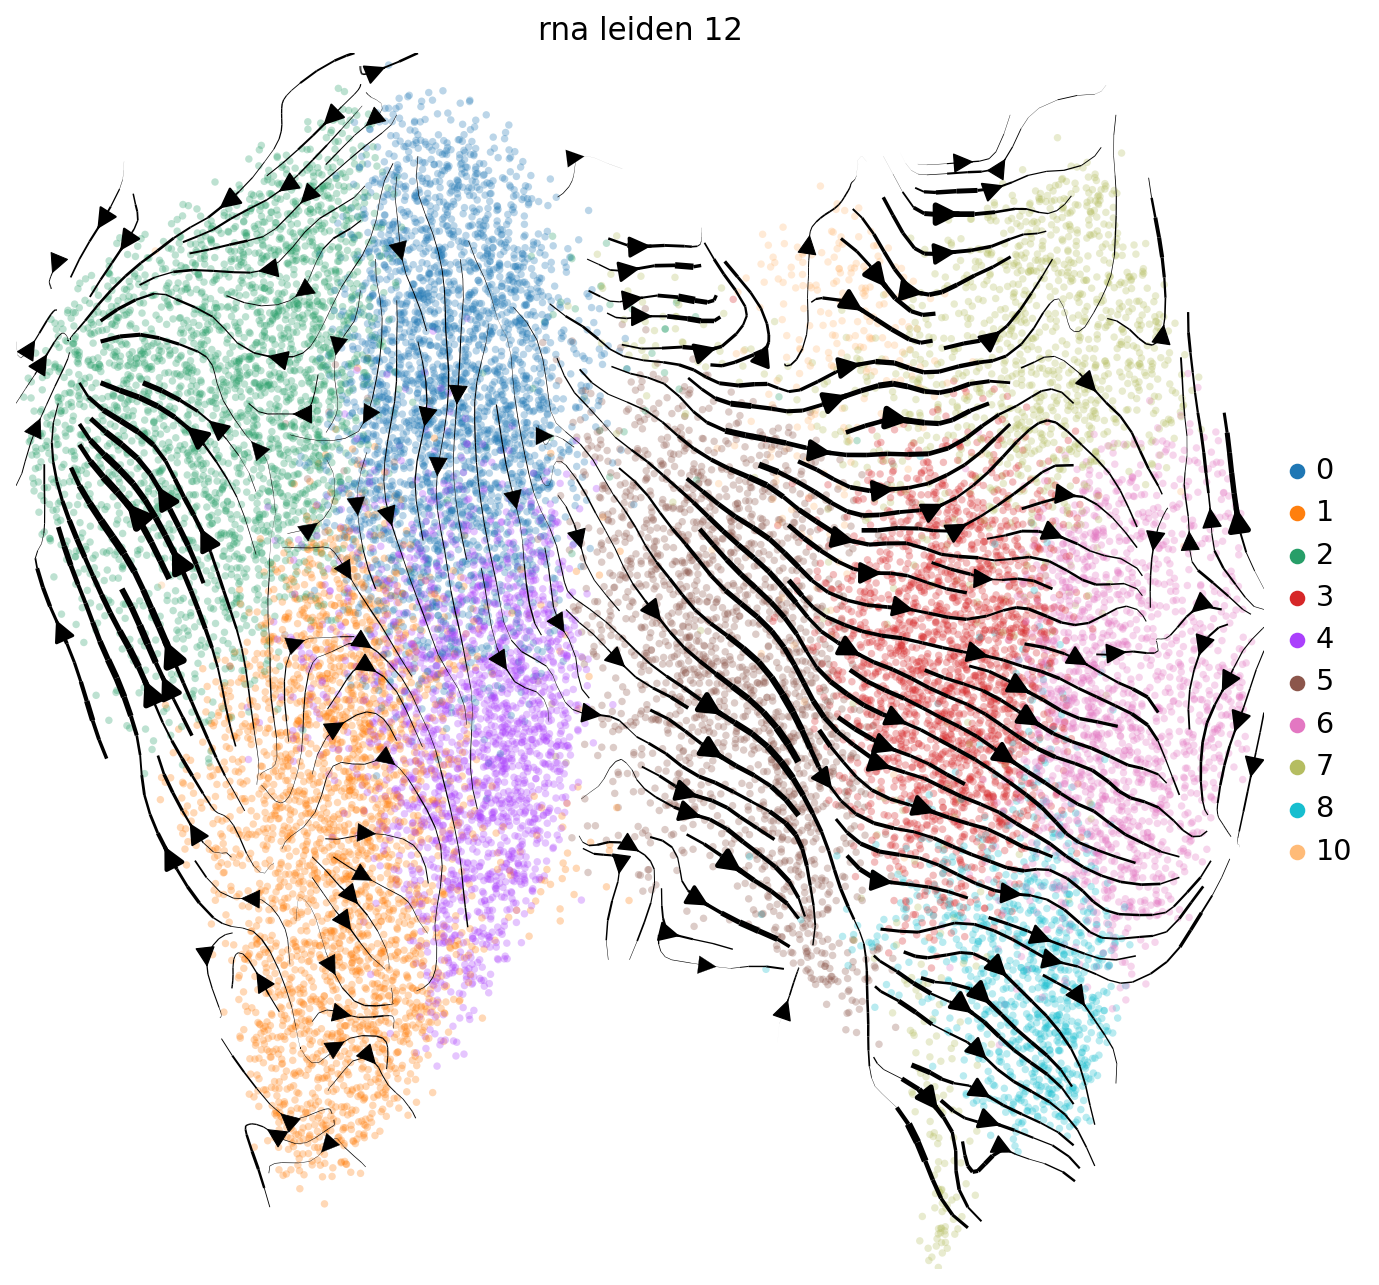

In [112]:
ax = sc.pl.embedding(
    adata,
    basis="X_umap",
    color="rna_leiden_12",
    show=False,
    legend_loc="None",
    size=45,
    alpha=0.3,frameon=False
)

scv.pl.velocity_embedding_stream(
    adata_scvelo,
    basis="X_umap",
    color="rna_leiden_12",arrow_size=2,linewidth=2,
    #     arrow_color="white",
    legend_loc="right margin",
    ax=ax,
    alpha=0, save = "velocity_normal_rna_leiden_12.png"
    #save = "velocity_normal_rna_leiden_12.svg"
)

ax.get_figure()

/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/kvalem/.conda/envs/scvelo_03_2024/lib/python3.10/site-packages/scvelo/plotting/utils.py:63: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/kvalem/.conda/envs/scvelo_03_2024/lib

saving figure to file /data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/publication_figures/healthy/scvelo_velocity_normal.png


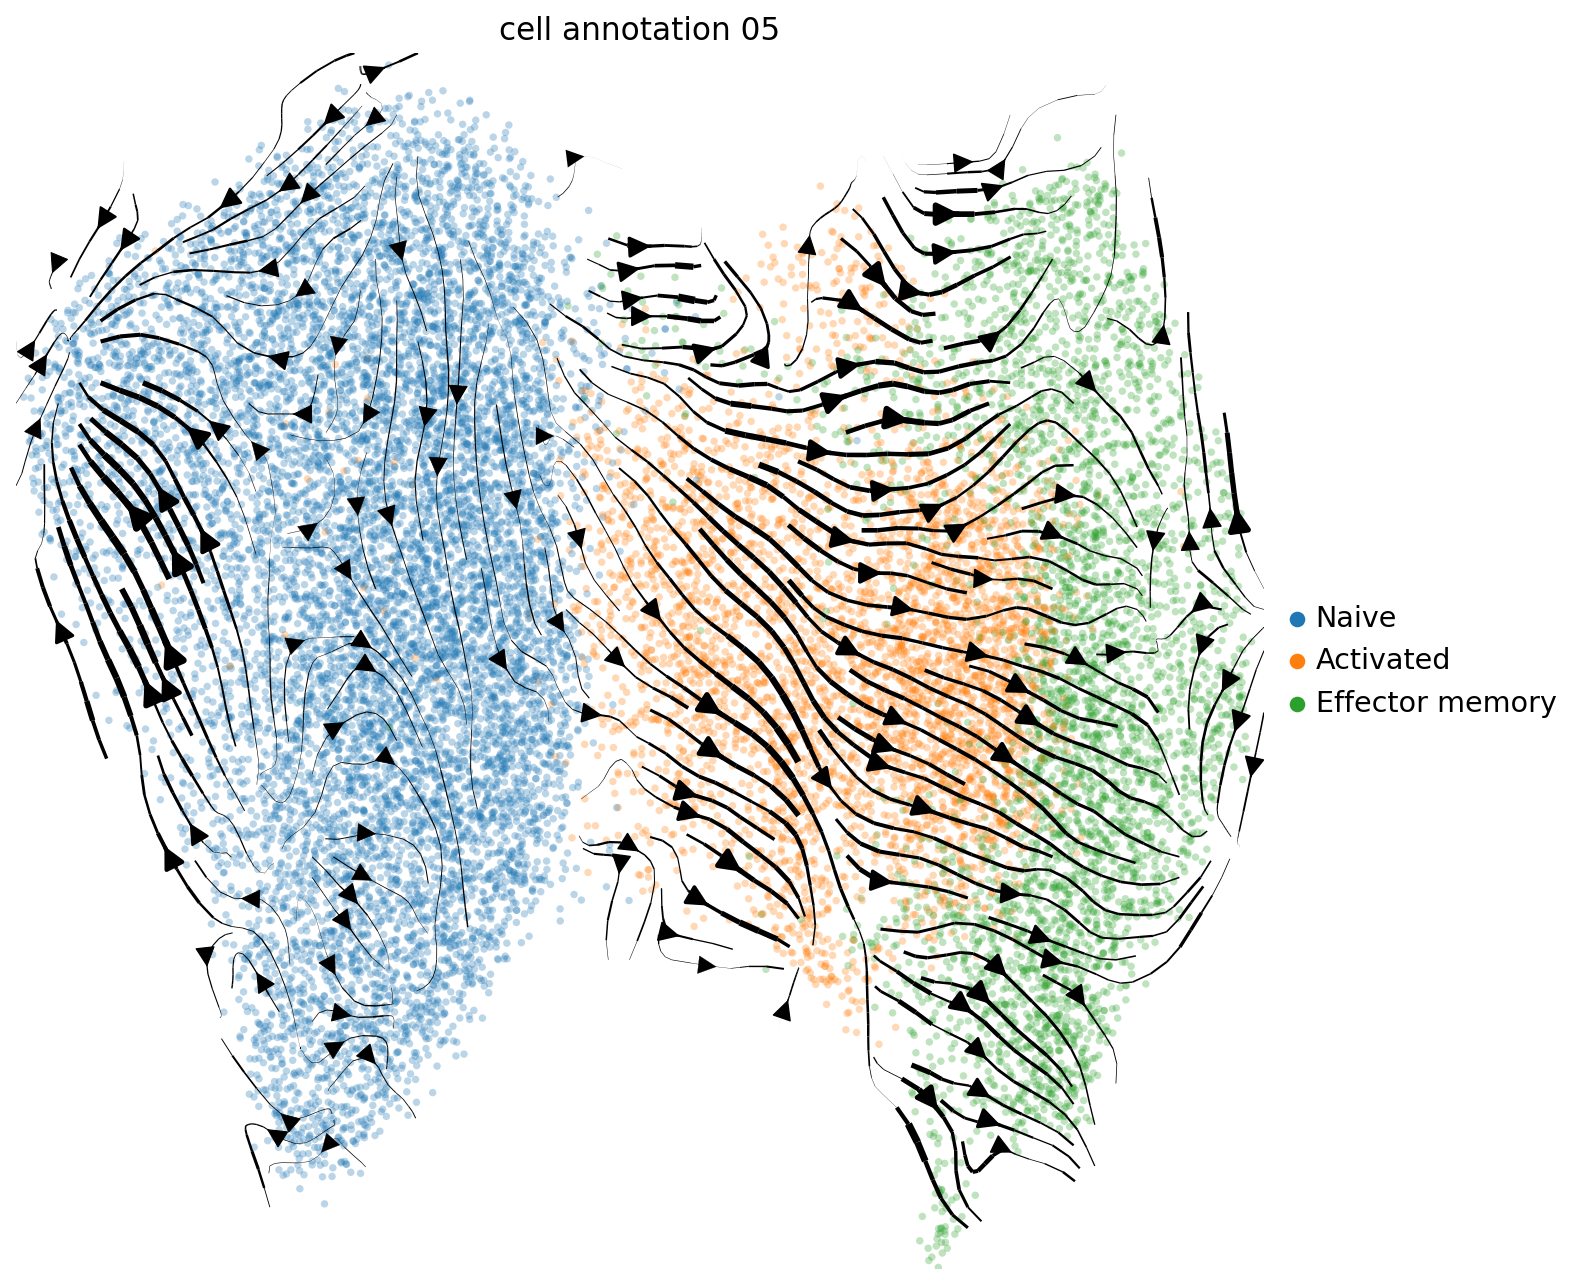

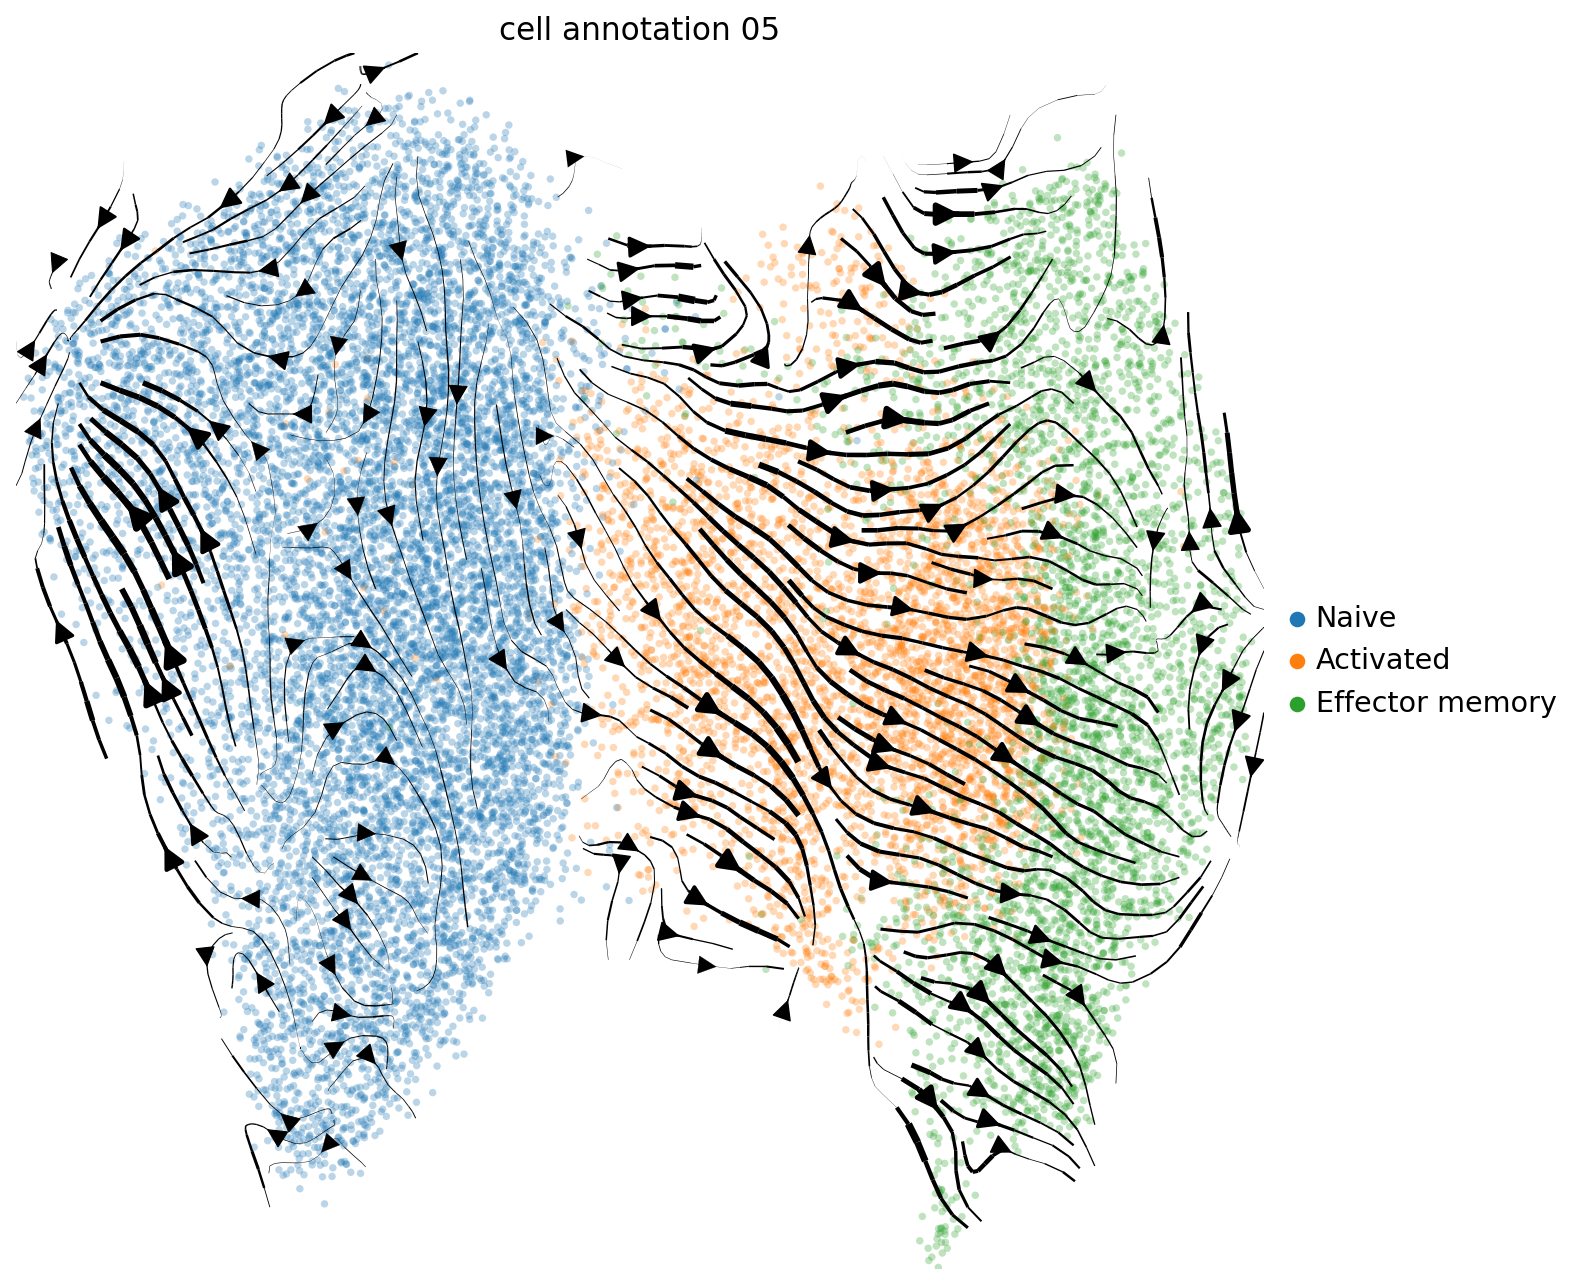

In [111]:
ax = sc.pl.embedding(
    adata,
    basis="X_umap",
    color="cell_annotation_05",
    show=False,
    legend_loc="None",
    size=45,
    alpha=0.3,frameon=False
)

scv.pl.velocity_embedding_stream(
    adata_scvelo,
    basis="X_umap",
    color="cell_annotation_05",arrow_size=2,linewidth=2,
    #     arrow_color="white",
    legend_loc="right margin",
    ax=ax,
    alpha=0, save ="velocity_normal.png" #save = "velocity_normal.svg"
)

ax.get_figure()